# Rank Estimation

## Human Observation


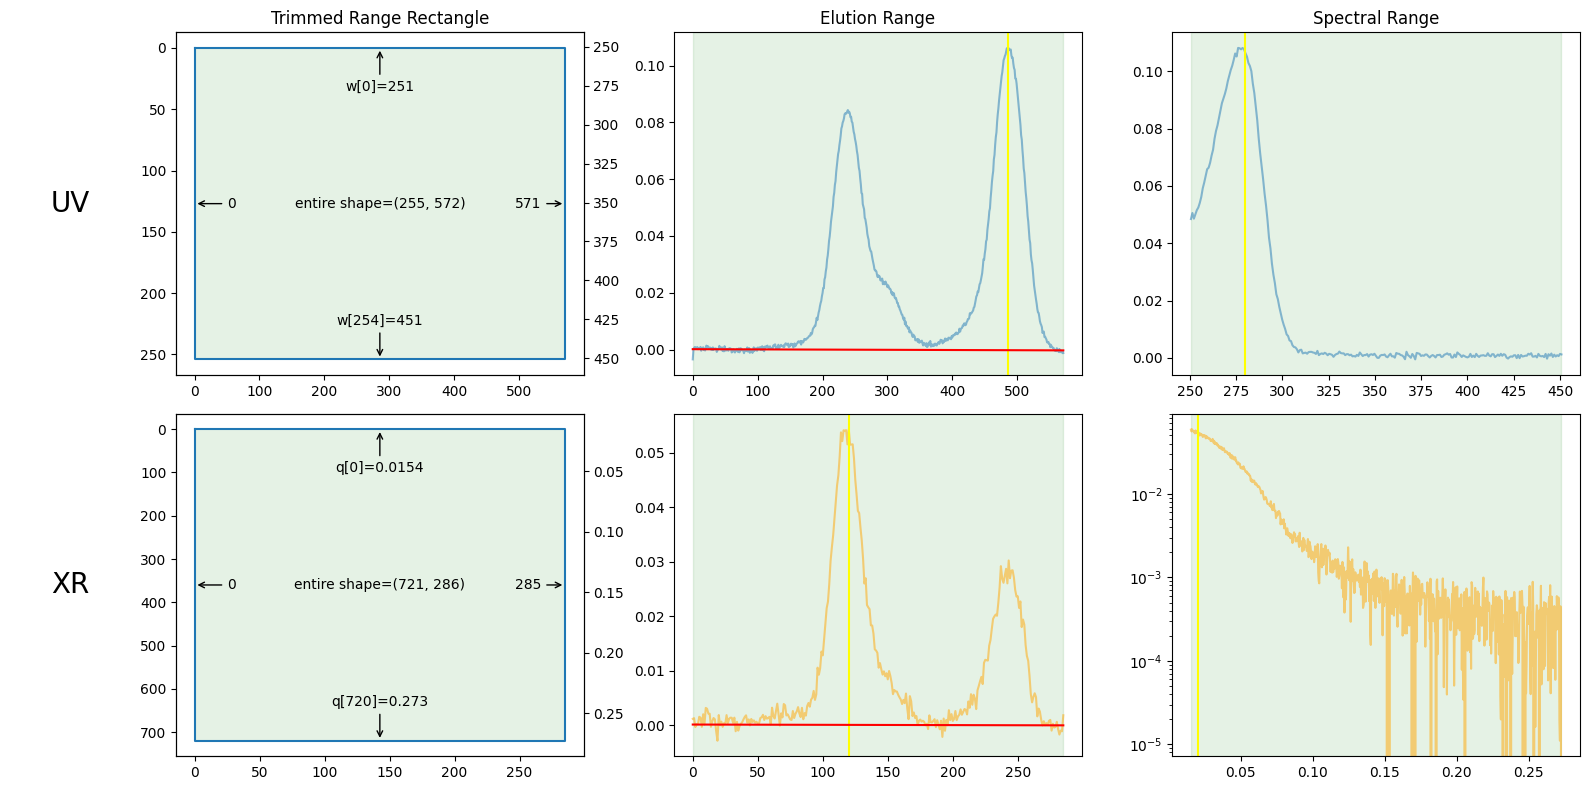

In [1]:
import sys
sys.path.insert(0, '../../../molass-library')
from molass_data import TUTORIAL_DATA
from molass.DataObjects import SecSaxsData as SSD
ssd = SSD(TUTORIAL_DATA)
trimmed_ssd = ssd.trimmed_copy()
corrected_ssd = trimmed_ssd.corrected_copy()
corrected_ssd.plot_trimming_info();


developer memo: remember that "LowRank.CoupledAdjuster.select_components" is not implemented yet.


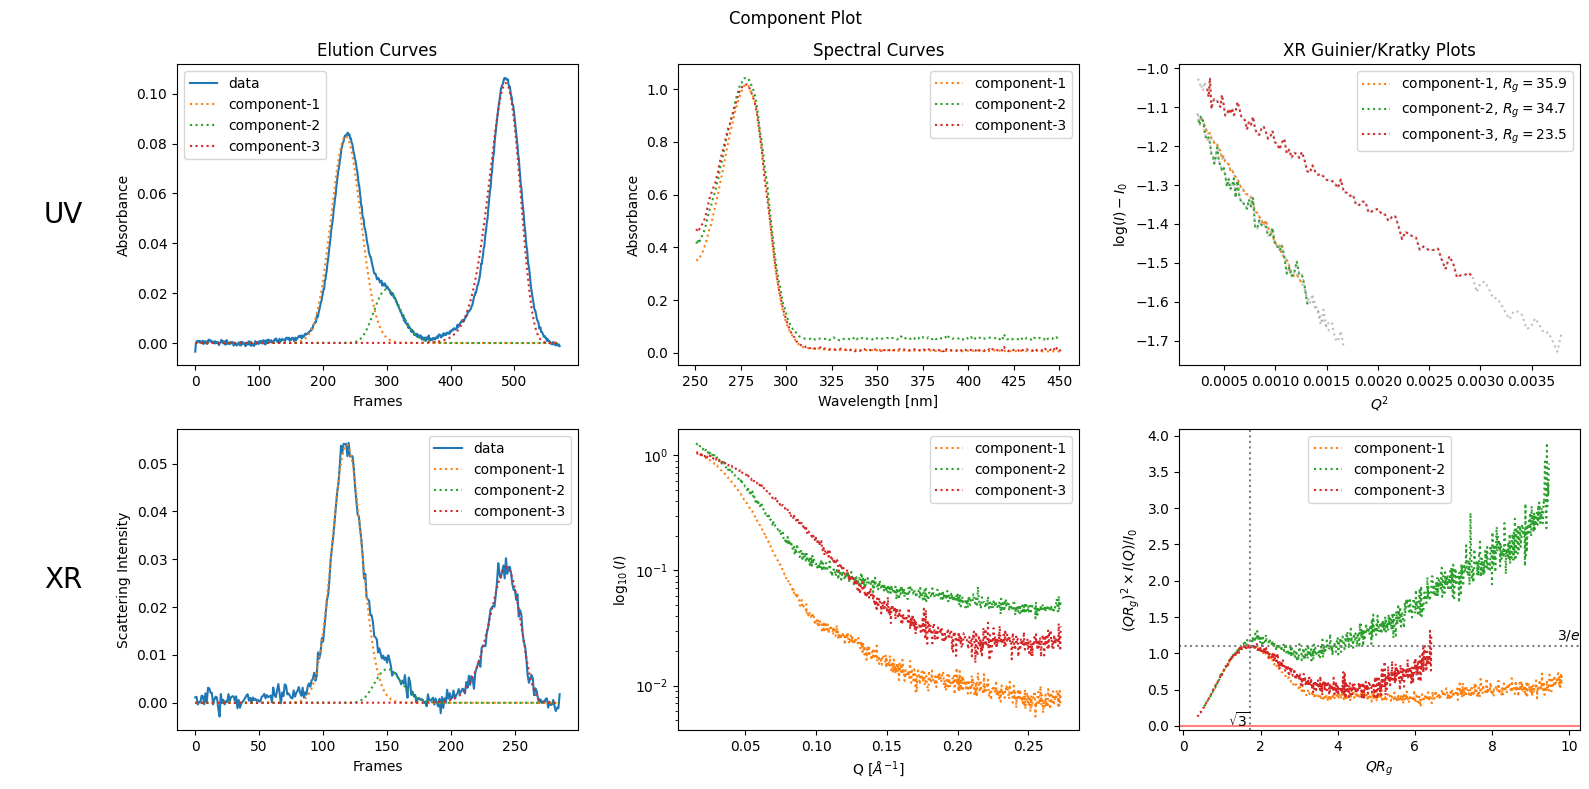

In [2]:
decomposition = corrected_ssd.quick_decomposition(num_components=3)
decomposition.plot_components();

## Absorbance / Scattering Ratio


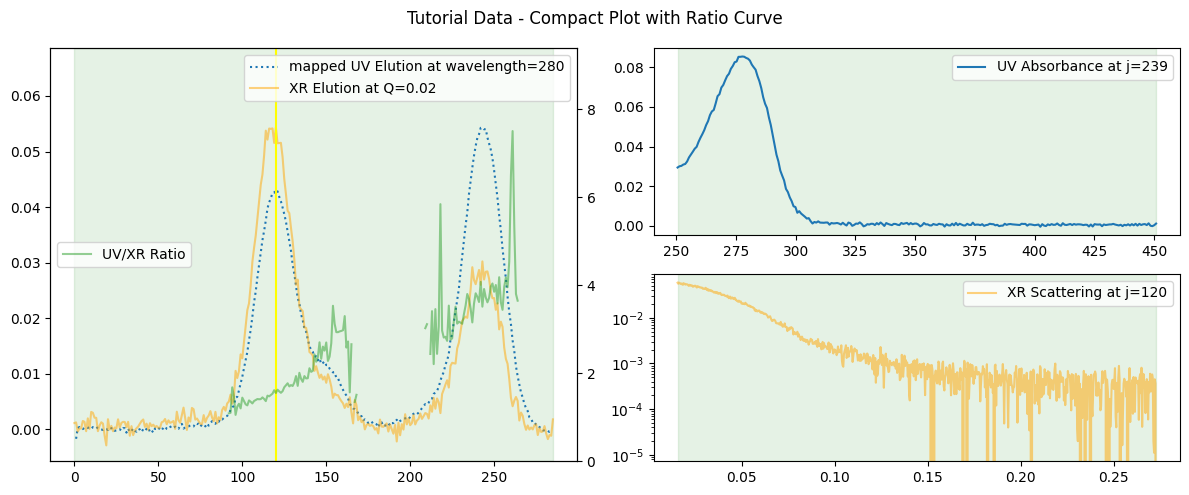

In [3]:
corrected_ssd.plot_compact(ratio_curve=True, title="Tutorial Data - Compact Plot with Ratio Curve");

## Concentration Dependence

In [4]:
scds = decomposition.compute_scds()
scds

[1, 1, 1]

In [5]:
from molass.LowRank.RankEstimator import scd_to_rank
ranks = [scd_to_rank(scd) for scd in scds]
for scd, rank in zip(scds, ranks):
    print(f"SCD: {scd}, Rank: {rank}")

SCD: 1, Rank: 1
SCD: 1, Rank: 1
SCD: 1, Rank: 1


In [6]:
decomposition.update_xr_ranks(ranks)
decomposition.get_xr_components()